# Code Assignment 16 — K-Means Clustering (Mall Customers, 2–3 Features Only)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:** Build a **K-Means** clustering model using **only 2–3 simple numeric features** with **minimal cleaning**, pick **K** via **Elbow + Silhouette** on the **train split**, and sanity-check **generalization** on the **test split**. Then profile clusters in plain business terms.

**Dataset (simple, non-transportation):** *Mall Customers* (public, widely used teaching dataset)  

> We will only use **2–3 numeric columns**: e.g., `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.  



## Instructor Guidance (Pseudocode + Docs)

**Docs:**  
- `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

### Pseudocode Plan (Minimal)
1) **Load CSV** → preview columns/shape.  
2) **Pick 2–3 numeric features** (e.g., Age, Income, SpendingScore).  
3) **Drop NA only** on those columns.  
4) **Split**: `train_test_split(X, test_size=0.2, random_state=42)`.  
5) **Scale**: `StandardScaler` — **fit on TRAIN**, transform TRAIN and TEST.  
6) **Choose K** on TRAIN: loop K=2..8 → plot **Elbow (inertia)** and **Silhouette**.  
7) **Fit final KMeans** on TRAIN with your chosen K; predict TRAIN & TEST labels.  
8) **Sanity check**: report **Silhouette (TRAIN vs TEST)**.  
9) **Profile clusters**: per-cluster means of your 2–3 features (no extra cleaning).  
10) **Reflection**: justify K, describe segments, suggest one action per segment.


## Your Task — Step-by-Step
Work in pairs. Keep code minimal. Use only 2–3 features.

### 1) Imports & Settings

In [68]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

### 2) Load the Mall Customers CSV & Preview

In [69]:
df = pd.read_csv("../data/Mall_Customers copy.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3) Select **2–3 Numeric Features** (no heavy cleaning)
Choose from:
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

> Keep it simple: e.g., use **Age + Spending Score** (2D) or **Age + Income + Spending Score** (3D).


In [70]:
X = df[['Age','Annual Income (k$)']]

display(X.describe())



,Age,Annual Income (k$)
count,200.000000,200.000000
mean,38.850000,60.560000
std,13.969007,26.264721
min,18.000000,15.000000
25%,28.750000,41.500000
50%,36.000000,61.500000
75%,49.000000,78.000000
max,70.000000,137.000000


### 4) Train–Test Split (for model generalization sanity check)

In [71]:
np.random.seed(16)
X_train, X_test = train_test_split(X, test_size=0.3, random_state=16)

### 5) Scale (fit on TRAIN only), then Explore K on TRAIN (Elbow + Silhouette)

In [107]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

### 6) Choose **K** (justify), Fit Final Model on TRAIN, Check Stability on TEST
- Report **Silhouette TRAIN vs TEST** (higher is better; similar values suggest stability).

In [74]:
wcss = [] # Within-Cluster Sum of Squares
silhouette = []
k_range = [2, 3, 4, 5, 6, 7, 8, 9]

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    # .inertia_ is the attribute that holds the WCSS value
    wcss.append(kmeans.inertia_) 
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))


wcss

[173.7620578256531,
 95.35166385937794,
 74.21979077286265,
 58.849163053182636,
 46.75081093704689,
 36.829534148817864,
 32.86692462263355,
 28.98179622485196]

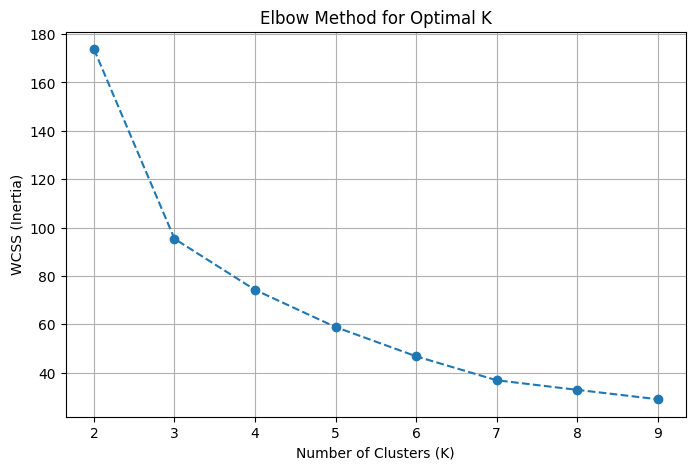

In [75]:
# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

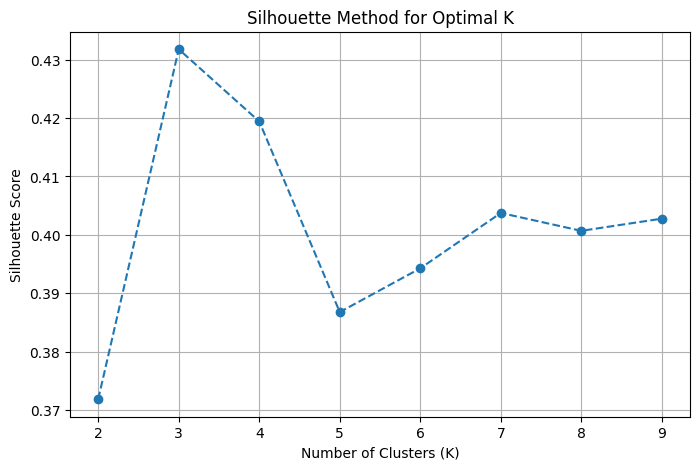

In [ ]:
# SILHOUETTE GRAPH FOR TRAIN DATA
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette, marker='o', linestyle='--')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

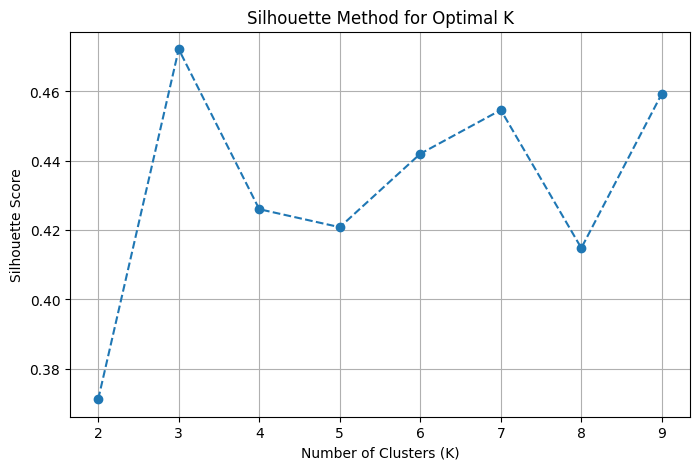

In [109]:
# SILHOUETTE TEST FOR TEST DATA

X_testscaled = scaler.fit_transform(X_test)

wcsstest = [] # Within-Cluster Sum of Squares
silhouettetest = []
k_rangetest = [2, 3, 4, 5, 6, 7, 8, 9]

for i in k_rangetest:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_testscaled)
    # .inertia_ is the attribute that holds the WCSS value
    wcsstest.append(kmeans.inertia_) 
    silhouettetest.append(silhouette_score(X_testscaled, kmeans.labels_))

# SILHOUETTE GRAPH FOR TRAIN DATA
plt.figure(figsize=(8, 5))
plt.plot(k_rangetest, silhouettetest, marker='o', linestyle='--')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_rangetest)
plt.grid(True)
plt.show()


### 7) Profile Clusters (Business-Readable)
- Use the **original (unscaled)** features for interpretation.
- Show per-cluster means of your **2–3 features**.

In [110]:
kmeansthree = KMeans(n_clusters=3,random_state=0)
kmeansthree.fit(X)

X['cluster'] = kmeansthree.labels_

X.groupby('cluster').mean()


/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_31847/1675506513.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster'] = kmeansthree.labels_


,Age,Annual Income (k$)
cluster,,
0,55.017241,51.293103
1,34.098901,82.912088
2,28.941176,31.215686


## We Share — Reflection (2 short paragraphs)

1) **K choice & stability:** What **K** did you choose and why (Elbow bend, Silhouette peak/plateau, simplicity)? Report **Silhouette (TRAIN vs TEST)** — did structure persist, or did it collapse on test?  

I chose 3 as my K because the elbow method shows a bend at our X axis of 3. I confirmed my decision for K by plotting the Silhouette Score, which also showed a peak at 3. I was also able to confirm by plotting the Silhouette Score of the test data, which had a similar shape and a peak on the X axis at 3.


2) **Segments & actions:** Give short names to your segments (e.g., “Young High-Spend,” “Mid-Age Value-Seeker,” “Older Low-Spend”) and suggest **one actionable idea** for each (targeted offers, product mix, messaging).

My three segments & recommendations would be:

**Older Average-Spend:**
- Maintain segment by providing mid tier discount codes (15%).
**Mid-Age High Spend:**
- Promote popular products based on trends of those around same age group.
**Younger Low-Spend:**
- Incentivize spending while remaining affordable by providing higher amount discount codes (25-40%).

> Bonus: Re-run with **just 2 features** (e.g., **Income + SpendingScore**) and compare stability & interpretability.
